# KDV PINN - Time Slice Visualization

This notebook demonstrates how to visualize the KDV solution as 1D spatial profiles at different times.

In [ ]:
# Add parent directory to path for imports
import sys
sys.path.insert(0, '../src')

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

from kdv_pinn.models import KdV_pinn, Siren
from kdv_pinn.physics import kdv, soliton_library, compute_conserved_integrals
from kdv_pinn.configuration import kdv_config, dict_to_config
from kdv_pinn.sampling import sample_slice, sample_bulk, extract_time_slices, extract_density_slices

# Modern matplotlib style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'
%matplotlib inline

## 1. Load Trained Model

In [2]:
# Option A: Load trained model
try:
    checkpoint = torch.load('pinn_model.pt', map_location='cpu')
    training_config = dict_to_config(checkpoint['config'])
    model = KdV_pinn(training_config)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("✓ Loaded trained model from pinn_model.pt")
except FileNotFoundError:
    # Option B: Use untrained model for demo
    print("⚠ No trained model found, using untrained model for demo")
    model = KdV_pinn(kdv_config)
    training_config = kdv_config

model.eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Model config: T={training_config.T}, L={training_config.L}")

✓ Loaded trained model from pinn_model.pt
Model config: T=1.0, L=10.0


In [3]:
from kdv_pinn.scattering import ScatteringData
kappas = [1.5, 0.97, 1.2, 1.3, 2]
x0s = [-5, 8, 10, 12, -4]
sd = ScatteringData(kappas, x0s, R=None, use_tau=True)
from kdv_pinn.models import AnalyticField
model = AnalyticField(sd.forward_fcn)

## 2. Extract Time Slices

In [4]:
# Select time values
t_values = [0.0, 0.25, 0.5, 0.75, 1.0]

# Create input tensor for the time slices
num_x_points = 300
x = torch.linspace(-training_config.L, training_config.L, num_x_points)
t_list = []
x_list = []
for t in t_values:
    t_tensor = torch.ones_like(x) * t
    t_list.append(t_tensor)
    x_list.append(x)
t_all = torch.cat(t_list)
x_all = torch.cat(x_list)
input_tensor = torch.stack([t_all, x_all], dim=1).to(device)

# Compute u using the model
u = model(input_tensor)

# Extract slices
slices = extract_time_slices(u, input_tensor, t_values, training_config, num_x_points=num_x_points)

print(f"Extracted {len(slices['t_values'])} time slices")
print(f"Spatial resolution: {len(slices['x'])} points")

Extracted 5 time slices
Spatial resolution: 300 points


## 3. Plot Temporal Evolution

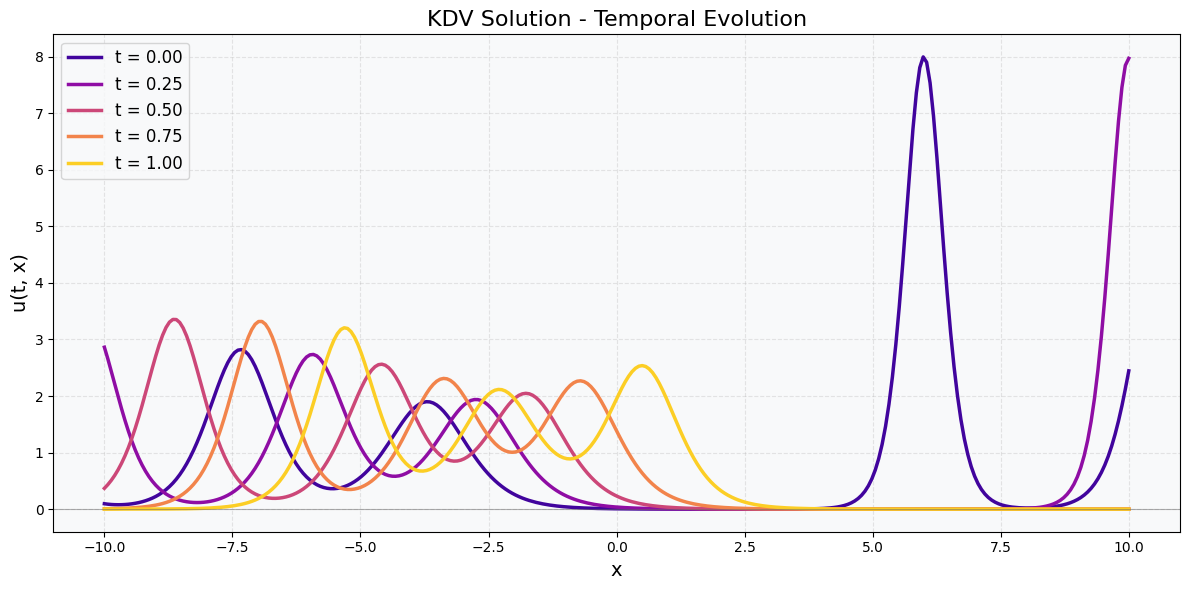

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_values)))

for idx, t in enumerate(slices['t_values']):
    ax.plot(slices['x'], slices['u_slices'][t], 
            color=colors[idx], linewidth=2.5, label=f't = {t:.2f}')

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('u(t, x)', fontsize=14)
ax.set_title('KDV Solution - Temporal Evolution', fontsize=16)
ax.legend(fontsize=12, loc='best')
ax.axhline(y=0, color='#666666', linestyle='-', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Compare with Exact Solution

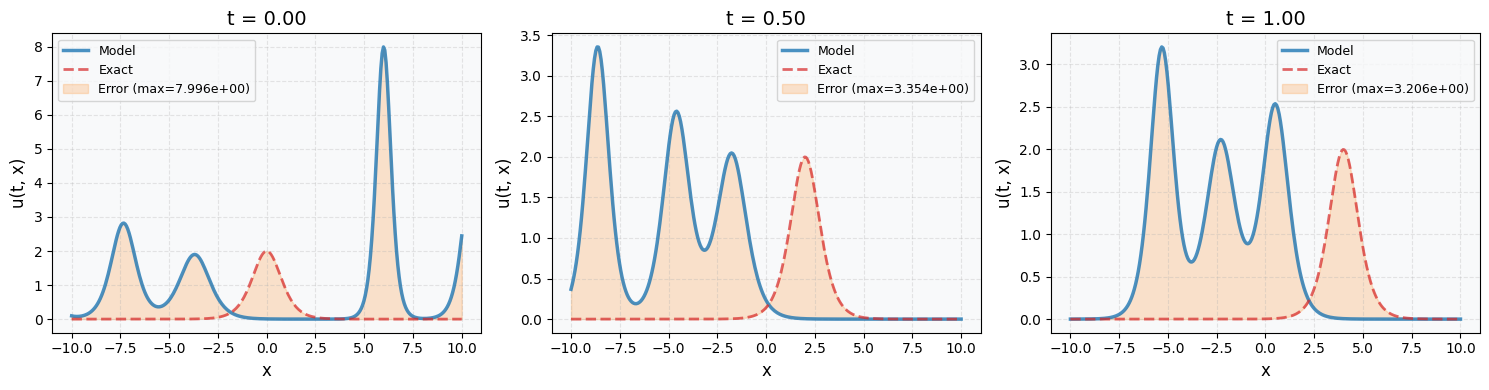

In [6]:
t_compare = [0.0, 0.5, 1.0]

fig, axes = plt.subplots(1, len(t_compare), figsize=(15, 4))

for idx, t in enumerate(t_compare):
    ax = axes[idx]
    
    # Model prediction
    x_model = slices['x']
    u_model = slices['u_slices'][t]
    
    # Exact solution
    x_exact = torch.tensor(x_model, dtype=torch.float32)
    t_exact = torch.ones_like(x_exact) * t
    input_exact = torch.stack([t_exact, x_exact], dim=1)
    soliton_fcn = soliton_library[training_config.soliton_type]
    u_exact = soliton_fcn(input_exact, training_config).numpy().flatten()
    
    # Plot
    ax.plot(x_model, u_model, color='#1f77b4', linewidth=2.5, label='Model', alpha=0.8)
    ax.plot(x_model, u_exact, color='#d62728', linestyle='--', linewidth=2, label='Exact', alpha=0.7)
    
    # Error
    error = np.abs(u_model - u_exact)
    ax.fill_between(x_model, u_model, u_exact, alpha=0.2, color='#ff7f0e', label=f'Error (max={error.max():.3e})')
    
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('u(t, x)', fontsize=12)
    ax.set_title(f't = {t:.2f}', fontsize=14)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Soliton Properties

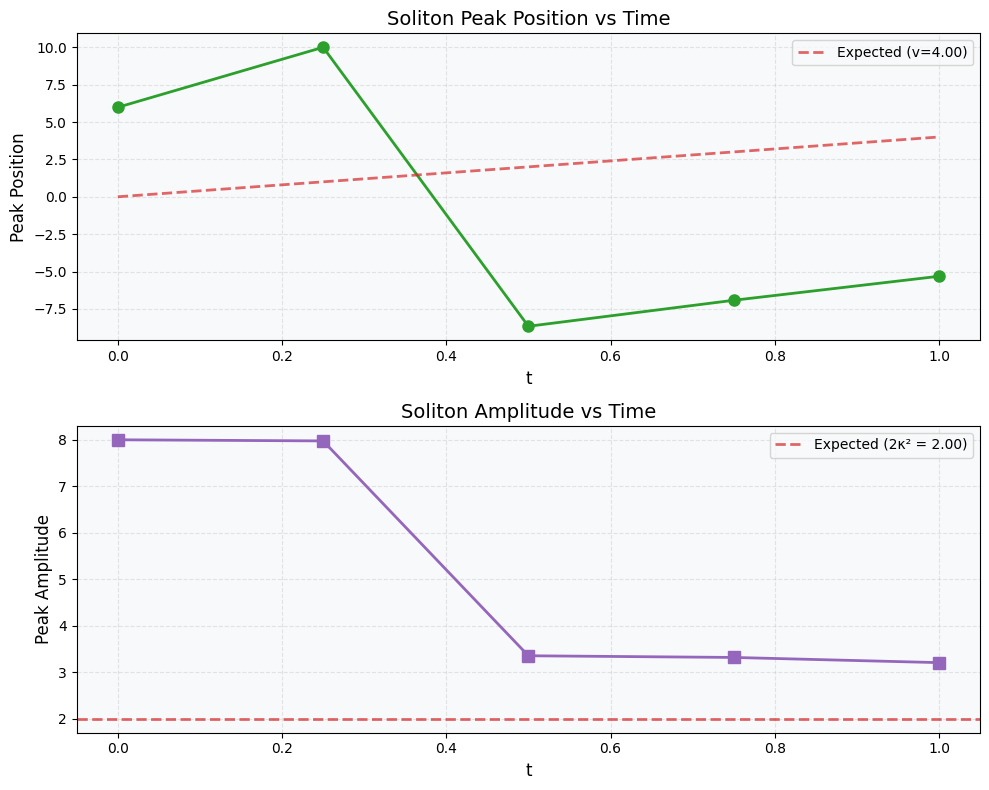

Expected velocity: 4.0000
Measured velocity (linear fit): -11.3043
Expected amplitude: 2.0000
Mean amplitude: 5.1692 ± 2.2985


In [7]:
# Track peak position and amplitude over time
peak_positions = []
peak_amplitudes = []

for t in slices['t_values']:
    u = slices['u_slices'][t]
    x = slices['x']
    
    # Find peak (maximum for positive soliton)
    idx_peak = np.argmax(u)
    peak_positions.append(x[idx_peak])
    peak_amplitudes.append(u[idx_peak])

# Plot evolution
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Peak position vs time
ax1.plot(slices['t_values'], peak_positions, 'o-', linewidth=2, markersize=8, color='#2ca02c')
ax1.set_xlabel('t', fontsize=12)
ax1.set_ylabel('Peak Position', fontsize=12)
ax1.set_title('Soliton Peak Position vs Time', fontsize=14)

# Calculate expected velocity: v = 4κ²
kappa = training_config.kappa
v_expected = 4 * kappa**2
t_array = np.array(slices['t_values'])
x_expected = training_config.x0 + v_expected * t_array
ax1.plot(t_array, x_expected, '--', linewidth=2, alpha=0.7, color='#d62728', label=f'Expected (v={v_expected:.2f})')
ax1.legend()

# Peak amplitude vs time
ax2.plot(slices['t_values'], peak_amplitudes, 's-', linewidth=2, markersize=8, color='#9467bd')
ax2.axhline(y=2*kappa**2, color='#d62728', linestyle='--', linewidth=2, alpha=0.7, label=f'Expected (2κ² = {2*kappa**2:.2f})')
ax2.set_xlabel('t', fontsize=12)
ax2.set_ylabel('Peak Amplitude', fontsize=12)
ax2.set_title('Soliton Amplitude vs Time', fontsize=14)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Expected velocity: {v_expected:.4f}")
print(f"Measured velocity (linear fit): {(peak_positions[-1] - peak_positions[0]) / (slices['t_values'][-1] - slices['t_values'][0]):.4f}")
print(f"Expected amplitude: {2*kappa**2:.4f}")
print(f"Mean amplitude: {np.mean(peak_amplitudes):.4f} ± {np.std(peak_amplitudes):.4f}")

## 6. Conserved Density Distributions

The KDV equation has conserved densities:
- u (field)
- ρ₁ = u²/2 (momentum density)
- ρ₂ = u³ + u_x²/2 (energy density)

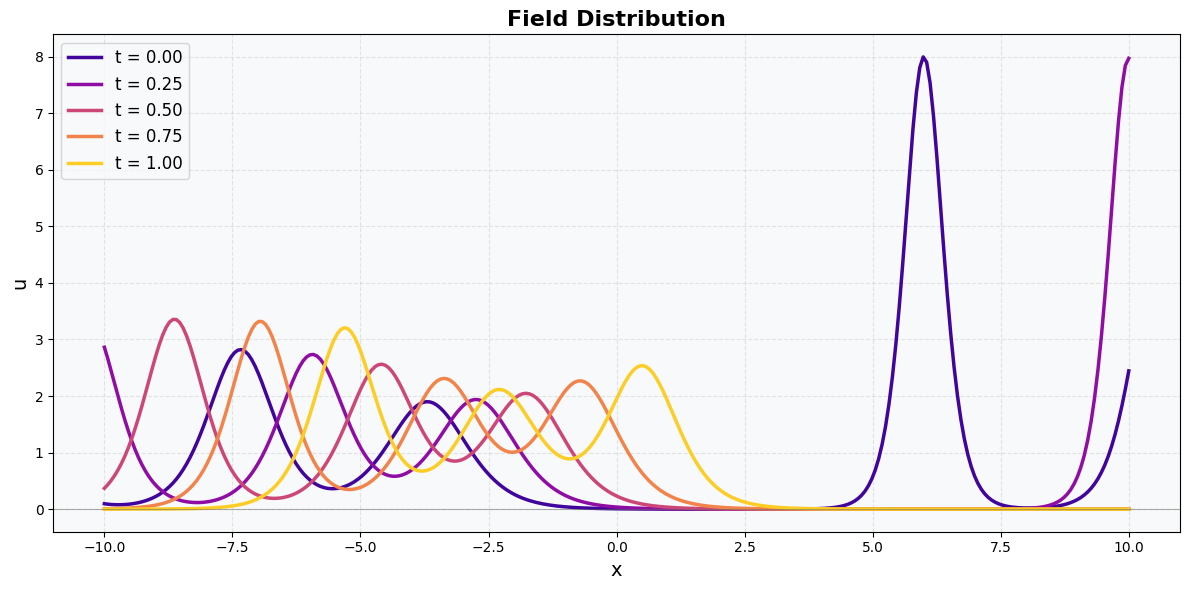

In [8]:
# Plot only u (field)
fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_values)))

for idx, t in enumerate(slices['t_values']):
    ax.plot(slices['x'], slices['u_slices'][t], 
            color=colors[idx], linewidth=2.5, label=f't = {t:.2f}')
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('u', fontsize=14)
ax.set_title('Field Distribution', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='best')
ax.axhline(y=0, color='#666666', linestyle='-', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

## 7. Conservation Law Verification

Conserved integrals computed:
  H_0(t=0) = 17.674752 (field integral)
  H_1(t=0) = 29.017328 (momentum)
  H_2(t=0) = -224.841702 (energy)


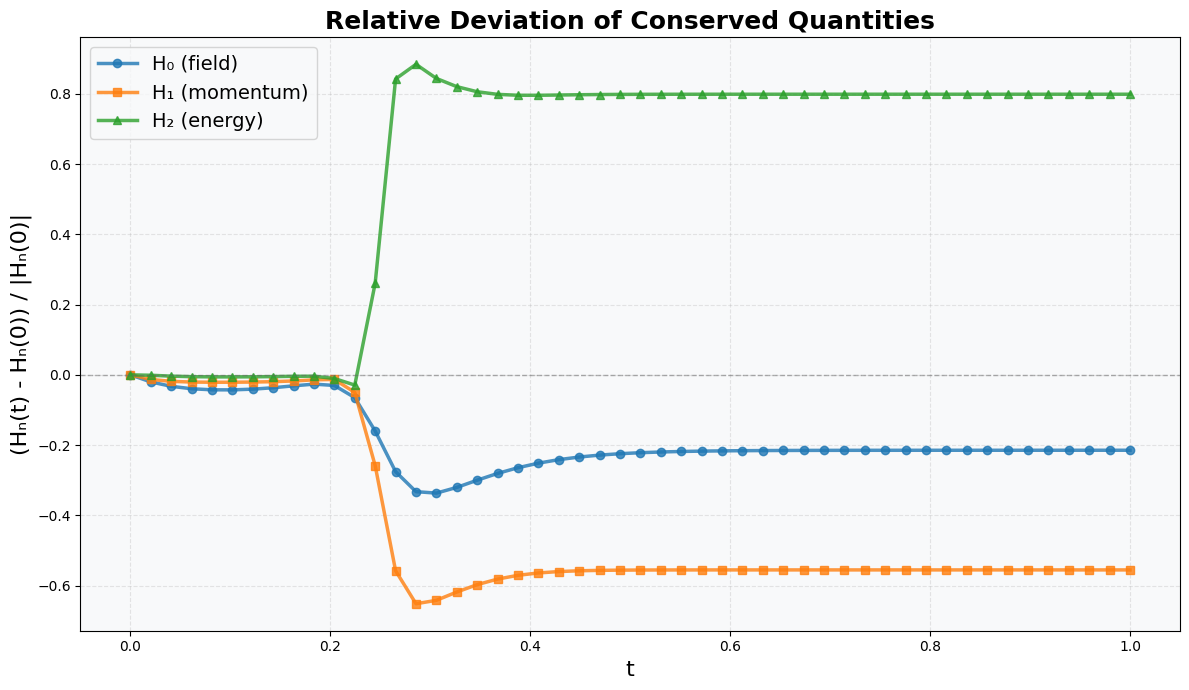


Maximum deviations:
  H₀: 3.367e-01
  H₁: 6.518e-01
  H₂: 8.843e-01


In [9]:
# Compute integrals over time
num_time_points = 50
t_integral = np.linspace(0, training_config.T, num_time_points)

integrals = compute_conserved_integrals(model, t_integral, training_config, num_x_points=500, device=device)

print("Conserved integrals computed:")
print(f"  H_0(t=0) = {integrals['H_0'][0]:.6f} (field integral)")
print(f"  H_1(t=0) = {integrals['H_1'][0]:.6f} (momentum)")
print(f"  H_2(t=0) = {integrals['H_2'][0]:.6f} (energy)")

# Compute relative deviations
H_0_dev = (integrals['H_0'] - integrals['H_0'][0]) / np.abs(integrals['H_0'][0])
H_1_dev = (integrals['H_1'] - integrals['H_1'][0]) / np.abs(integrals['H_1'][0])
H_2_dev = (integrals['H_2'] - integrals['H_2'][0]) / np.abs(integrals['H_2'][0])

# Plot deviations
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(integrals['t_values'], H_0_dev, 'o-', linewidth=2.5, markersize=6, 
        color='#1f77b4', label='H₀ (field)', alpha=0.8)
ax.plot(integrals['t_values'], H_1_dev, 's-', linewidth=2.5, markersize=6, 
        color='#ff7f0e', label='H₁ (momentum)', alpha=0.8)
ax.plot(integrals['t_values'], H_2_dev, '^-', linewidth=2.5, markersize=6, 
        color='#2ca02c', label='H₂ (energy)', alpha=0.8)

ax.axhline(y=0, color='#666666', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('t', fontsize=16)
ax.set_ylabel('(Hₙ(t) - Hₙ(0)) / |Hₙ(0)|', fontsize=16)
ax.set_title('Relative Deviation of Conserved Quantities', fontsize=18, fontweight='bold')
ax.legend(fontsize=14, loc='best')
ax.ticklabel_format(style='scientific', axis='y', scilimits=(-3,3))

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nMaximum deviations:")
print(f"  H₀: {np.max(np.abs(H_0_dev)):.3e}")
print(f"  H₁: {np.max(np.abs(H_1_dev)):.3e}")
print(f"  H₂: {np.max(np.abs(H_2_dev)):.3e}")

## Create Animation of Traveling Wave

In [10]:
# Extract many time slices for smooth animation
num_frames = 60
t_anim = np.linspace(0, training_config.T, num_frames)

# Create input tensor
num_x_points = 300
x = torch.linspace(-training_config.L, training_config.L, num_x_points)
t_list = []
x_list = []
for t in t_anim:
    t_tensor = torch.ones_like(x) * t
    t_list.append(t_tensor)
    x_list.append(x)
t_all = torch.cat(t_list)
x_all = torch.cat(x_list)
input_tensor = torch.stack([t_all, x_all], dim=1).to(device)

# Compute u
u = model(input_tensor)

# Extract slices
anim_slices = extract_time_slices(u, input_tensor, t_anim, training_config, num_x_points=num_x_points)

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))
x_plot = anim_slices['x']

# Initialize plot elements
line_model, = ax.plot([], [], 'b-', linewidth=3, label='Model')
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=14, 
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Set axis limits
y_min = min(anim_slices['u_slices'][t].min() for t in t_anim)
y_max = max(anim_slices['u_slices'][t].max() for t in t_anim)
ax.set_xlim(x_plot.min(), x_plot.max())
ax.set_ylim(y_min * 1.2, y_max * 1.2)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('u(t, x)', fontsize=14)
ax.set_title('KDV Solution Propagation', fontsize=16, fontweight='bold')
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)

def init():
    line_model.set_data([], [])
    time_text.set_text('')
    return line_model, time_text

def animate(frame):
    t = t_anim[frame]
    
    # Update model prediction
    u_model = anim_slices['u_slices'][t]
    line_model.set_data(x_plot, u_model)
    
    # Update time text
    time_text.set_text(f't = {t:.3f}')
    
    return line_model, time_text

# Create animation
anim = FuncAnimation(fig, animate, init_func=init, frames=num_frames, 
                     interval=50, blit=True, repeat=True)

# Display in notebook
plt.close()
HTML(anim.to_jshtml())

In [ ]:
# Extract many time slices for animation with eigenstates
num_frames = 60
t_anim = np.linspace(0, training_config.T, num_frames)

# Create input tensor for u
num_x_points = 300
x = torch.linspace(-training_config.L, training_config.L, num_x_points)
t_list = []
x_list = []
for t in t_anim:
    t_tensor = torch.ones_like(x) * t
    t_list.append(t_tensor)
    x_list.append(x)
t_all = torch.cat(t_list)
x_all = torch.cat(x_list)
input_tensor_anim = torch.stack([t_all, x_all], dim=1).to(device)

# Compute u
u_anim = model(input_tensor_anim)

# Compute eigenstates slice by slice
psi_slices = {}
for n in range(sd.Ns):
    psi_slices[n] = {}

x_np = np.linspace(-training_config.L, training_config.L, num_x_points)

for t_val in t_anim:
    x_tensor = torch.tensor(x_np, dtype=torch.float32, device=device).unsqueeze(-1)
    t_tensor = torch.ones_like(x_tensor) * t_val
    
    for n in range(sd.Ns):
        psi_n = sd.psi(x_tensor, t_tensor, n).detach().cpu().numpy().flatten()
        psi_slices[n][t_val] = psi_n

# Extract u slices
u_anim_slices = extract_time_slices(u_anim, input_tensor_anim, t_anim, training_config, num_x_points=num_x_points)

# Create figure with eigenstates
fig, ax = plt.subplots(figsize=(14, 7))
x_plot = u_anim_slices['x']

# Initialize plot elements
line_u, = ax.plot([], [], 'k-', linewidth=3, label='u(t,x)', zorder=10)
line_psi = []
colors = plt.cm.viridis(np.linspace(0, 1, sd.Ns))
for n in range(sd.Ns):
    line, = ax.plot([], [], '-', linewidth=2, color=colors[n], label=f'ψ_{n}', alpha=0.7)
    line_psi.append(line)

time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=14, 
                    verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Set axis limits
y_min_u = min(u_anim_slices['u_slices'][t].min() for t in t_anim)
y_max_u = max(u_anim_slices['u_slices'][t].max() for t in t_anim)
y_min_psi = min(psi_slices[n][t].min() for n in range(sd.Ns) for t in t_anim)
y_max_psi = max(psi_slices[n][t].max() for n in range(sd.Ns) for t in t_anim)

y_min = min(y_min_u, y_min_psi)
y_max = max(y_max_u, y_max_psi)

ax.set_xlim(x_plot.min(), x_plot.max())
ax.set_ylim(y_min * 1.2, y_max * 1.2)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('Amplitude', fontsize=14)
ax.set_title('KDV Solution and Eigenstates', fontsize=16, fontweight='bold')
ax.legend(fontsize=10, loc='upper right', ncol=2)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)

def init():
    line_u.set_data([], [])
    for line in line_psi:
        line.set_data([], [])
    time_text.set_text('')
    return [line_u] + line_psi + [time_text]

def animate(frame):
    t = t_anim[frame]
    
    # Update u
    u_vals = u_anim_slices['u_slices'][t]
    line_u.set_data(x_plot, u_vals)
    
    # Update eigenstates
    for n in range(sd.Ns):
        psi_vals = psi_slices[n][t]
        line_psi[n].set_data(x_plot, psi_vals)
    
    # Update time text
    time_text.set_text(f't = {t:.3f}')
    
    return [line_u] + line_psi + [time_text]

# Create animation
anim = FuncAnimation(fig, animate, init_func=init, frames=num_frames, 
                     interval=50, blit=True, repeat=True)

# Display in notebook
plt.close()
HTML(anim.to_jshtml())